# Imports

In [ ]:
import pandas as pd
import numpy as np

!pip install rdkit

from rdkit import Chem
from rdkit.Chem import Crippen

from rdkit.Chem import Descriptors
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import umap

from IPython.display import display

from rdkit.DataStructs import TanimotoSimilarity


# Data set antibiotics

In [314]:
df_ab = pd.read_excel("ab_raw_clean.xlsx", engine = "openpyxl")

# Remove duplicates
df_ab = df_ab.drop_duplicates(subset = "chembl_id")

df_ab.reset_index(drop = True, inplace = True)

# Add oisitive class
df_ab["is_antibiotic"] = 1

print(df_ab.head())

     chembl_id  mol_weight  alogp  \
0   CHEMBL1439      322.28  -1.52   
1  CHEMBL44354      546.59  -1.30   
2    CHEMBL996      427.46   0.10   
3     CHEMBL32      401.44   2.37   
4   CHEMBL1730      455.47  -0.62   

                                              smiles  is_antibiotic  
0  C[C@]1(Cn2ccnn2)[C@H](C(=O)[O-])N2C(=O)C[C@H]2...              1  
1  CC(C)(O/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=...              1  
2  CO[C@@]1(NC(=O)Cc2cccs2)C(=O)N2C(C(=O)O)=C(COC...              1  
3  COc1c(N2C[C@@H]3CCCN[C@@H]3C2)c(F)cc2c(=O)c(C(...              1  
4  CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...              1  


In [315]:
df_ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 759 entries, 0 to 758
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   chembl_id      759 non-null    object 
 1   mol_weight     758 non-null    float64
 2   alogp          738 non-null    float64
 3   smiles         756 non-null    object 
 4   is_antibiotic  759 non-null    int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 29.8+ KB


In [316]:
# Check for Null val.
null_counts = df_ab.isnull().sum()

print(null_counts[null_counts > 0])

mol_weight     1
alogp         21
smiles         3
dtype: int64


In [317]:
#Deal with Null val.

df_ab = df_ab[~df_ab["smiles"].isin([None, "None", ""])]
df_ab = df_ab.reset_index(drop=True)

# 2. Recalcular AlogP apenas onde está ausente
def calculate_alogp(smiles, current_value):
    if pd.isna(current_value) and isinstance(smiles, str):
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Crippen.MolLogP(mol)
    return current_value

df_ab["alogp"] = df_ab.apply(lambda row: calculate_alogp(row["smiles"], row["alogp"]), axis = 1)

df_ab = df_ab.dropna()

print("Null val. per column:")
print(df_ab.isnull().sum())

Null val. per column:
chembl_id        0
mol_weight       0
alogp            0
smiles           0
is_antibiotic    0
dtype: int64


In [318]:
# check smiles
df_ab["valid_smiles"] = df_ab["smiles"].apply(lambda x: Chem.MolFromSmiles(str(x)) is not None)

In [319]:

invalid_count = (~df_ab["valid_smiles"]).sum()

print(f"invalid smiles found: {invalid_count}")

invalid smiles found: 0


In [320]:
df_ab.columns.tolist()

['chembl_id', 'mol_weight', 'alogp', 'smiles', 'is_antibiotic', 'valid_smiles']

In [321]:
df_ab["smiles"].value_counts(dropna=False).head(10)

,count
smiles,
c1ccc2[nH]c(-c3cscn3)nc2c1,1
C[C@]1(Cn2ccnn2)[C@H](C(=O)[O-])N2C(=O)C[C@H]2S1(=O)=O.[Na+],1
CC(C)(O/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n+]3ccccc3)CS[C@H]12)c1csc(N)n1)C(=O)O,1
CO[C@@]1(NC(=O)Cc2cccs2)C(=O)N2C(C(=O)O)=C(COC(N)=O)CS[C@@H]21,1
O=C(O)c1cccnc1,1
CSc1nc2cc(Cl)c(Oc3cccc(Cl)c3Cl)cc2[nH]1,1
COc1cc(C)c(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)c(C)c1C,1
CC(CN1c2ccccc2Sc2ccccc21)N(C)C.Cl,1
Nc1nnc(-c2cccc(Cl)c2Cl)c(N)n1,1


In [322]:
# 1. Remove rows with invalid smiles
df_ab = df_ab[df_ab["valid_smiles"] == True].copy()

# 2. Null value count
missing_values = df_ab.isna().sum()
print("Missing val. per column after invalid smiles removal:")
print(missing_values)

Missing val. per column after invalid smiles removal:
chembl_id        0
mol_weight       0
alogp            0
smiles           0
is_antibiotic    0
valid_smiles     0
dtype: int64


In [323]:
# check again
invalid_count = (~df_ab["valid_smiles"]).sum()
print(f" not valid SMILES: {invalid_count}")

 not valid SMILES: 0


In [324]:
df_ab.reset_index(drop = True, inplace = True)
df_ab.drop(columns = ["valid_smiles"], inplace = True)

In [325]:
# dtypes
df_ab["chembl_id"] = df_ab["chembl_id"].astype(str)
df_ab["smiles"] = df_ab["smiles"].astype(str)

df_ab["mol_weight"] = df_ab["mol_weight"] # Removed .str.replace(",", ".").astype(float)
df_ab["alogp"] = df_ab["alogp"] # Removed .astype(float)

In [326]:
df_ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   chembl_id      756 non-null    object 
 1   mol_weight     756 non-null    float64
 2   alogp          756 non-null    float64
 3   smiles         756 non-null    object 
 4   is_antibiotic  756 non-null    int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 29.7+ KB


In [327]:
# Descriptors with RDKit
def calculate_rdkit_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return {
            'logP': Descriptors.MolLogP(mol),
            'num_h_donors': Descriptors.NumHDonors(mol),
            'num_h_acceptors': Descriptors.NumHAcceptors(mol),
            'num_rotatable_bonds': Descriptors.NumRotatableBonds(mol),
            'TPSA': Descriptors.TPSA(mol),
            'num_rings': Descriptors.RingCount(mol),
        }
    else:
        return {k: None for k in [
            "mol_weight_calc", "logP", "num_h_donors",
            "num_h_acceptors", "num_rotatable_bonds", "TPSA", "num_rings"
        ]}

# Funtional groups
functional_groups = {
    "carboxylic_acid": "C(=O)O",
    "ether": "COC",
    "ester": "C(=O)OC",
    "amine": "N",
    "amide": "C(=O)N",
    "ketone": "C(=O)C",
    "aldehyde": "[CX3H1](=O)[#6]",
    "nitrile": "C#N",
    "aromatic_ring": "a",
    "haloalkene": "C=C[Cl,Br,I,F]",
    "sulfonamide": "S(=O)(=O)N",
    "acryl_halide": "C(=O)Cl",
    "nitro": "[N+](=O)[O-]",
    "alcohol": "CO",
    "alkene": "C=C",
}


functional_group_mols = {}
for name, smarts in functional_groups.items():
    pattern = Chem.MolFromSmarts(smarts)
    if pattern:
        functional_group_mols[name] = pattern
    else:
        print(f"SMARTS inválido para '{name}': {smarts}")


def detect_functional_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {fg: False for fg in functional_group_mols}
    return {
        fg: mol.HasSubstructMatch(pattern)
        for fg, pattern in functional_group_mols.items()
    }

rdkit_props = df_ab["smiles"].apply(calculate_rdkit_properties)
df_props = pd.DataFrame(rdkit_props.tolist())

group_flags = df_ab["smiles"].apply(detect_functional_groups)
df_groups = pd.DataFrame(group_flags.tolist())

# Concatenate with df_ab
df_ab = pd.concat([df_ab.reset_index(drop=True),
                   df_props.reset_index(drop=True),
                   df_groups.reset_index(drop=True)], axis=1)

# drop AlogP column
if "alogp" in df_ab.columns:
    df_ab = df_ab.drop(columns = ["alogp"])


In [328]:
df_ab.head()

,chembl_id,mol_weight,smiles,is_antibiotic,logP,num_h_donors,num_h_acceptors,num_rotatable_bonds,TPSA,num_rings,...,ketone,aldehyde,nitrile,aromatic_ring,haloalkene,sulfonamide,acryl_halide,nitro,alcohol,alkene
0,CHEMBL1439,322.28,C[C@]1(Cn2ccnn2)[C@H](C(=O)[O-])N2C(=O)C[C@H]2...,1,-5.85,0,8,3,125.29,3,...,True,False,False,True,False,False,False,False,True,False
1,CHEMBL44354,546.59,CC(C)(O/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=...,1,-1.30,3,11,9,191.22,4,...,True,False,False,True,False,False,False,False,True,True
2,CHEMBL996,427.46,CO[C@@]1(NC(=O)Cc2cccs2)C(=O)N2C(C(=O)O)=C(COC...,1,0.10,3,8,7,148.26,3,...,True,False,False,True,False,False,False,False,True,True
3,CHEMBL32,401.44,COc1c(N2C[C@@H]3CCCN[C@@H]3C2)c(F)cc2c(=O)c(C(...,1,2.37,2,6,4,83.80,5,...,False,False,False,True,False,False,False,False,True,False
4,CHEMBL1730,455.47,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,1,-0.62,3,11,7,173.51,3,...,True,False,False,True,False,False,False,False,True,True


In [329]:
df_ab.columns.to_list()

['chembl_id',
 'mol_weight',
 'smiles',
 'is_antibiotic',
 'logP',
 'num_h_donors',
 'num_h_acceptors',
 'num_rotatable_bonds',
 'TPSA',
 'num_rings',
 'carboxylic_acid',
 'ether',
 'ester',
 'amine',
 'amide',
 'ketone',
 'aldehyde',
 'nitrile',
 'aromatic_ring',
 'haloalkene',
 'sulfonamide',
 'acryl_halide',
 'nitro',
 'alcohol',
 'alkene']

In [330]:
# ECFP4
morgan_generator = GetMorganGenerator(radius = 2, fpSize = 1024)


def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = morgan_generator.GetFingerprint(mol)
        arr = np.zeros((1024,), dtype = int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    else:
        return np.zeros((1024,), dtype = int)  # vetor nulo para SMILES inválido


ecfp_features = np.array(df_ab["smiles"].apply(smiles_to_ecfp).to_list())


ecfp_df = pd.DataFrame(ecfp_features, columns = [f"ECFP4_{i}" for i in range(1024)])

# Concat
df_ab = pd.concat([df_ab.reset_index(drop = True), ecfp_df.reset_index(drop = True)], axis = 1)

print("ECFP4 features added using MorganGenerator. Final shape:", df_ab.shape)


ECFP4 features added using MorganGenerator. Final shape: (756, 1049)


# EDA df_ab

,mol_weight,is_antibiotic,logP,num_h_donors,num_h_acceptors,num_rotatable_bonds,TPSA,num_rings
count,756.00,756.00,756.00,756.00,756.00,756.00,756.00,756.00
mean,386.60,1.00,1.73,2.49,5.74,5.08,102.45,2.92
std,202.86,0.00,2.79,3.14,4.27,4.50,86.70,1.60
min,34.01,1.00,-11.55,0.00,0.00,0.00,0.00,0.00
25%,275.19,1.00,0.19,1.00,3.00,2.00,52.28,2.00
50%,353.36,1.00,2.08,2.00,5.00,4.00,86.18,3.00
75%,444.50,1.00,3.59,3.00,7.00,7.00,124.01,4.00
max,2296.97,1.00,7.49,36.00,38.00,59.00,947.18,12.00


<Figure size 1200x500 with 0 Axes>

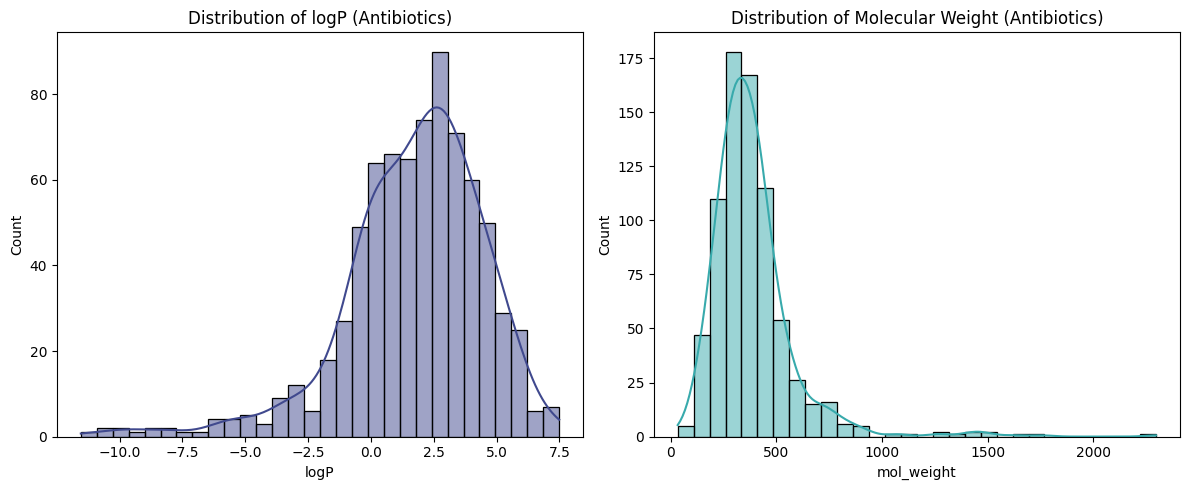

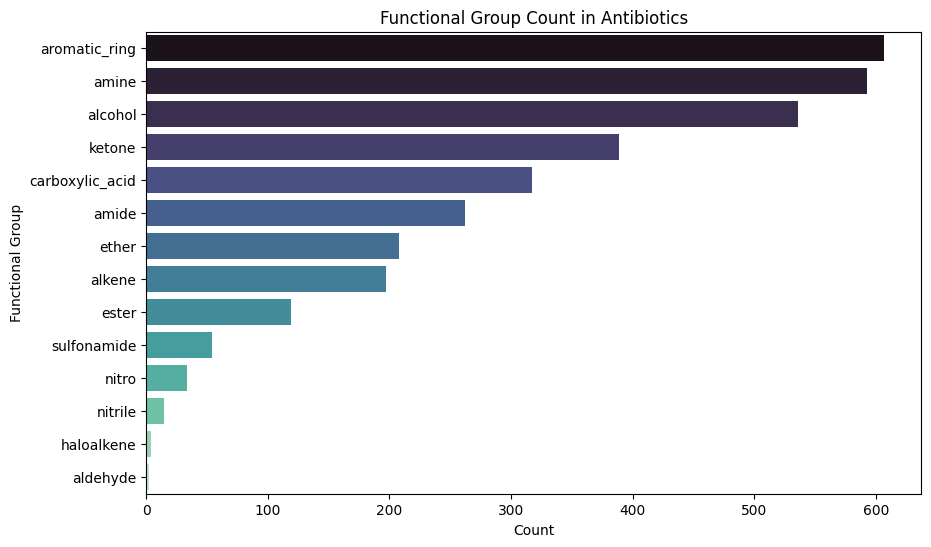

In [331]:
# Remove ECFP4 columns (those starting with 'ECFP4_')
df_ab_describe = df_ab.loc[:, ~df_ab.columns.str.startswith("ECFP4_")]

# Stats
display(df_ab_describe.describe())


plt.figure(figsize = (12, 5))

mako_colors = sns.color_palette("mako", n_colors=2)

plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_ab["logP"], kde = True, bins = 30, color = mako_colors[0])
plt.title("Distribution of logP (Antibiotics)")

plt.subplot(1, 2, 2)
df_ab["mol_weight"] = df_ab["mol_weight"].astype(float)
sns.histplot(df_ab["mol_weight"], kde=True, bins=30, color=mako_colors[1])
plt.title("Distribution of Molecular Weight (Antibiotics)")

plt.tight_layout()
plt.show()

# group counts
functional_columns = [
    "carboxylic_acid", "ether", "ester", "amine", "amide", "ketone", "aldehyde",
    "nitrile", "aromatic_ring", "haloalkene", "sulfonamide", "nitro", "alcohol", "alkene"
]

fg_counts = df_ab[functional_columns].sum().sort_values(ascending = False)

plt.figure(figsize = (10, 6))
sns.barplot(x = fg_counts.values, y = fg_counts.index, palette = "mako")
plt.title("Functional Group Count in Antibiotics")
plt.xlabel("Count")
plt.ylabel("Functional Group")
plt.show()

the fucntional group acryl_halide is not present in df_ab

In [332]:
df_ab = df_ab.drop(columns = ["acryl_halide"], errors = "ignore")

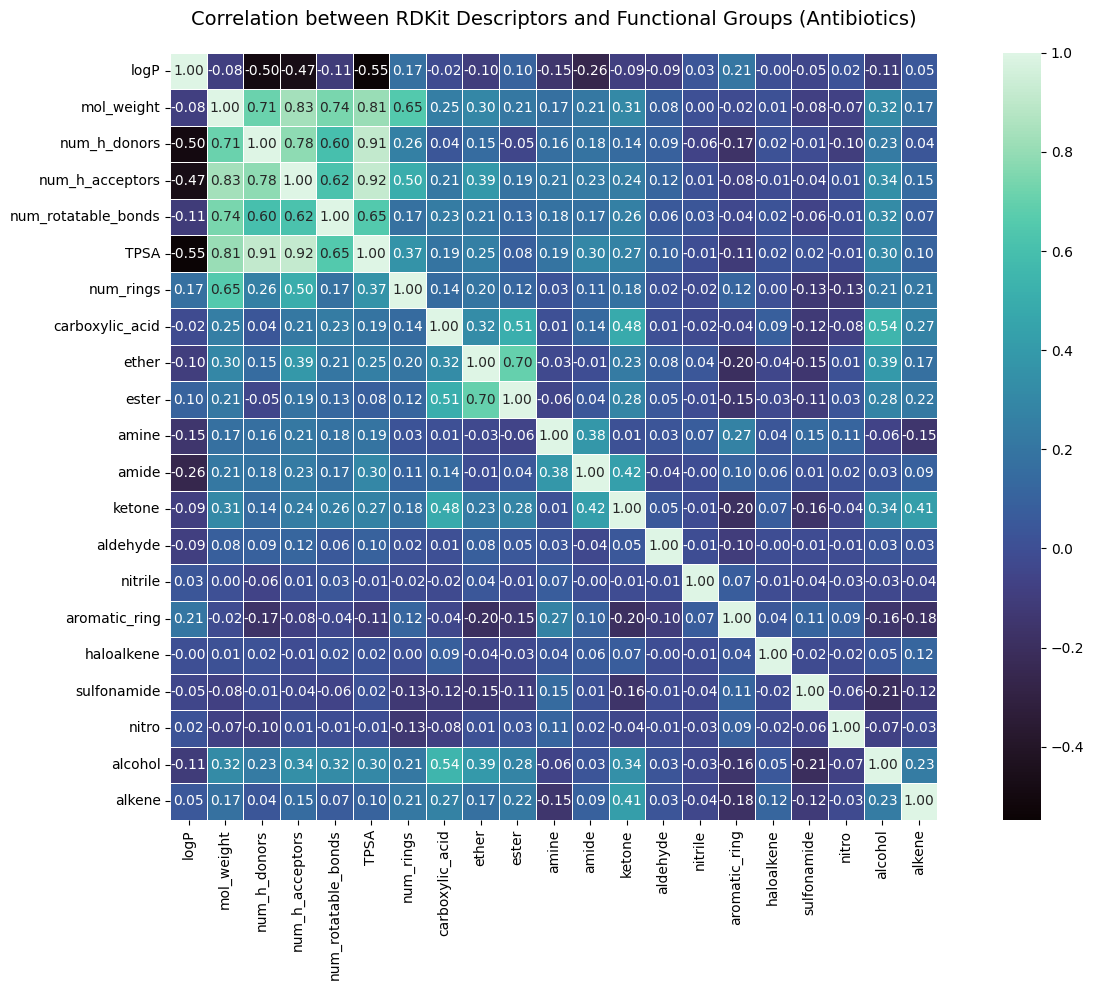

In [333]:
#columns for the heatmap
descriptor_columns = [
    "logP", "mol_weight", "num_h_donors", "num_h_acceptors",
    "num_rotatable_bonds", "TPSA", "num_rings"
]

functional_columns = [
    "carboxylic_acid", "ether", "ester", "amine", "amide", "ketone", "aldehyde",
    "nitrile", "aromatic_ring", "haloalkene", "sulfonamide", "nitro", "alcohol", "alkene"
]


selected_cols = descriptor_columns + functional_columns
df_analysis = df_ab[selected_cols].copy()


df_analysis = df_analysis.apply(pd.to_numeric, errors = "coerce")


correlation_matrix = df_analysis.corr()

# Plot
plt.figure(figsize = (14, 10))
sns.heatmap(correlation_matrix, annot = True, fmt = ".2f", cmap = "mako", square = True, linewidths = 0.5)
plt.title("Correlation between RDKit Descriptors and Functional Groups (Antibiotics)", fontsize = 14, pad = 20)
plt.tight_layout()
plt.show()

# Data set non-antibiotics

In [334]:

df_non_ab = pd.read_csv("non_ab_approved_clean.csv", sep=';')

# Remove chembl_id duplicates
df_non_ab = df_non_ab.drop_duplicates(subset="chembl_id")

# Remove "None"
df_non_ab = df_non_ab[~df_non_ab["chembl_id"].isin(["None", None])]
df_non_ab = df_non_ab[~df_non_ab["smiles"].isin(["None", None])]
df_non_ab = df_non_ab.dropna(subset=["chembl_id", "smiles"])

# add negative class
df_non_ab["is_antibiotic"] = 0


df_non_ab["valid_smiles"] = df_non_ab["smiles"].apply(lambda x: Chem.MolFromSmiles(x) is not None)


invalid_count = (~df_non_ab["valid_smiles"]).sum()
print(f"invalid SMILE count: {invalid_count}")

[23:41:36] WARNING: not removing hydrogen atom without neighbors
[23:41:36] WARNING: not removing hydrogen atom without neighbors
[23:41:36] WARNING: not removing hydrogen atom without neighbors
[23:41:36] WARNING: not removing hydrogen atom without neighbors


invalid SMILE count: 0


In [335]:
# RDKit
def calc_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return pd.Series({
            "molecular_weight": Descriptors.MolWt(mol),
            "logP": Descriptors.MolLogP(mol),
            "num_h_donors": Descriptors.NumHDonors(mol),
            "num_h_acceptors": Descriptors.NumHAcceptors(mol),
            "num_rotatable_bonds": Descriptors.NumRotatableBonds(mol),
            "TPSA": Descriptors.TPSA(mol),
            "num_rings": Descriptors.RingCount(mol),
        })
    else:
        return pd.Series({
            "molecular_weight": None,
            "logP": None,
            "num_h_donors": None,
            "num_h_acceptors": None,
            "num_rotatable_bonds": None,
            "TPSA": None,
            "num_rings": None,
        })

props = df_non_ab["smiles"].apply(calc_props)
df_non_ab = pd.concat([df_non_ab.reset_index(drop=True), props.reset_index(drop = True)], axis = 1)


df_non_ab = df_non_ab[~df_non_ab["chembl_id"].isin(df_ab["chembl_id"])]

#
print(f"Final df with {df_non_ab.shape[0]} FDA-approved non-antibiotics.")

[23:41:39] WARNING: not removing hydrogen atom without neighbors
[23:41:39] WARNING: not removing hydrogen atom without neighbors
[23:41:39] WARNING: not removing hydrogen atom without neighbors
[23:41:39] WARNING: not removing hydrogen atom without neighbors


✅ Final df with 1506 FDA-approved non-antibiotics.


In [336]:
df_non_ab.columns.to_list()

['chembl_id',
 'smiles',
 'is_antibiotic',
 'valid_smiles',
 'molecular_weight',
 'logP',
 'num_h_donors',
 'num_h_acceptors',
 'num_rotatable_bonds',
 'TPSA',
 'num_rings']

In [337]:
df_non_ab.head()

,chembl_id,smiles,is_antibiotic,valid_smiles,molecular_weight,logP,num_h_donors,num_h_acceptors,num_rotatable_bonds,TPSA,num_rings
0,CHEMBL730,O=[N+]([O-])OCC(CO[N+](=O)[O-])O[N+](=O)[O-],0,True,227.08,-1.02,0.00,9.00,8.00,157.11,0.00
1,CHEMBL492,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,0,True,276.42,3.75,1.00,2.00,7.00,32.34,1.00
2,CHEMBL878,Cc1ccccc1N1C(=O)c2cc(S(N)(=O)=O)c(Cl)cc2NC1C,0,True,365.84,2.71,2.00,4.00,2.00,92.50,3.00
3,CHEMBL1079604,Cc1cc(C)cc(OCC2CNC(=O)O2)c1,0,True,221.26,1.79,1.00,3.00,3.00,47.56,2.00
5,CHEMBL1200436,C[C@]12COC(=O)C[C@@H]1CC[C@@H]1[C@@H]2CC[C@@]2...,0,True,306.45,3.54,1.00,3.00,0.00,46.53,4.00


In [338]:
df_non_ab.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1506 entries, 0 to 1851
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   chembl_id            1506 non-null   object 
 1   smiles               1506 non-null   object 
 2   is_antibiotic        1506 non-null   int64  
 3   valid_smiles         1506 non-null   bool   
 4   molecular_weight     1506 non-null   float64
 5   logP                 1506 non-null   float64
 6   num_h_donors         1506 non-null   float64
 7   num_h_acceptors      1506 non-null   float64
 8   num_rotatable_bonds  1506 non-null   float64
 9   TPSA                 1506 non-null   float64
 10  num_rings            1506 non-null   float64
dtypes: bool(1), float64(7), int64(1), object(2)
memory usage: 130.9+ KB


In [339]:
# Morgan (ECFP4)
generator = GetMorganGenerator(radius=2, fpSize=1024)


def ecfp4_with_generator(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0] * 1024
    fp = generator.GetFingerprint(mol)
    arr = np.zeros((1,), dtype = int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


ecfp_array = df_non_ab["smiles"].apply(ecfp4_with_generator)
df_ecfp = pd.DataFrame(ecfp_array.tolist(), columns = [f"ECFP4_{i}" for i in range(1024)])

# df concat
df_non_ab = pd.concat([df_non_ab.reset_index(drop = True), df_ecfp.reset_index(drop = True)], axis = 1)

print("ECFP4 (com MorganGenerator) adicionados.")

# funtional groups
functional_groups = {
    "carboxylic_acid": "C(=O)O",
    "ether": "COC",
    "ester": "C(=O)OC",
    "amine": "N",
    "amide": "C(=O)N",
    "ketone": "C(=O)C",
    "aldehyde": "[CX3H1](=O)[#6]",
    "nitrile": "C#N",
    "aromatic_ring": "a",
    "haloalkene": "C=C[Cl,Br,I,F]",
    "sulfonamide": "S(=O)(=O)N",
    "nitro": "[N+](=O)[O-]",
    "alcohol": "CO",
    "alkene": "C=C",
}


fg_mols = {name: Chem.MolFromSmarts(smarts) for name, smarts in functional_groups.items() if Chem.MolFromSmarts(smarts)}


def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {name: False for name in fg_mols}
    return {name: mol.HasSubstructMatch(pattern) for name, pattern in fg_mols.items()}


group_flags = df_non_ab["smiles"].apply(detect_groups)
df_groups = pd.DataFrame(group_flags.tolist())

# Concat
df_non_ab = pd.concat([df_non_ab.reset_index(drop = rue), df_groups.reset_index(drop = True)], axis = 1)

print("Functionsl groups added.")


[23:41:44] WARNING: not removing hydrogen atom without neighbors
[23:41:44] WARNING: not removing hydrogen atom without neighbors
[23:41:44] WARNING: not removing hydrogen atom without neighbors
[23:41:44] WARNING: not removing hydrogen atom without neighbors


✅ ECFP4 (com MorganGenerator) adicionados.


[23:41:49] WARNING: not removing hydrogen atom without neighbors
[23:41:49] WARNING: not removing hydrogen atom without neighbors
[23:41:49] WARNING: not removing hydrogen atom without neighbors
[23:41:49] WARNING: not removing hydrogen atom without neighbors


Functionsl groups added.


In [340]:
df_non_ab = df_non_ab.drop(columns = ["valid_smiles"], errors  "ignore")

# EDA df_non_ab

,is_antibiotic,molecular_weight,logP,num_h_donors,num_h_acceptors,num_rotatable_bonds,TPSA,num_rings
count,1506.00,1506.00,1506.00,1506.00,1506.00,1506.00,1506.00,1506.00
mean,0.00,371.02,3.02,1.69,4.67,5.54,75.04,3.02
std,0.00,175.45,2.69,1.72,2.99,5.67,53.35,1.79
min,0.00,60.05,-14.24,0.00,0.00,0.00,0.00,0.00
25%,0.00,265.35,1.77,1.00,3.00,3.00,40.54,2.00
50%,0.00,344.36,3.06,1.00,4.00,5.00,65.64,3.00
75%,0.00,437.53,4.29,2.00,6.00,7.00,97.78,4.00
max,0.00,2750.26,55.89,20.00,31.00,125.00,627.07,13.00


<Figure size 1200x500 with 0 Axes>

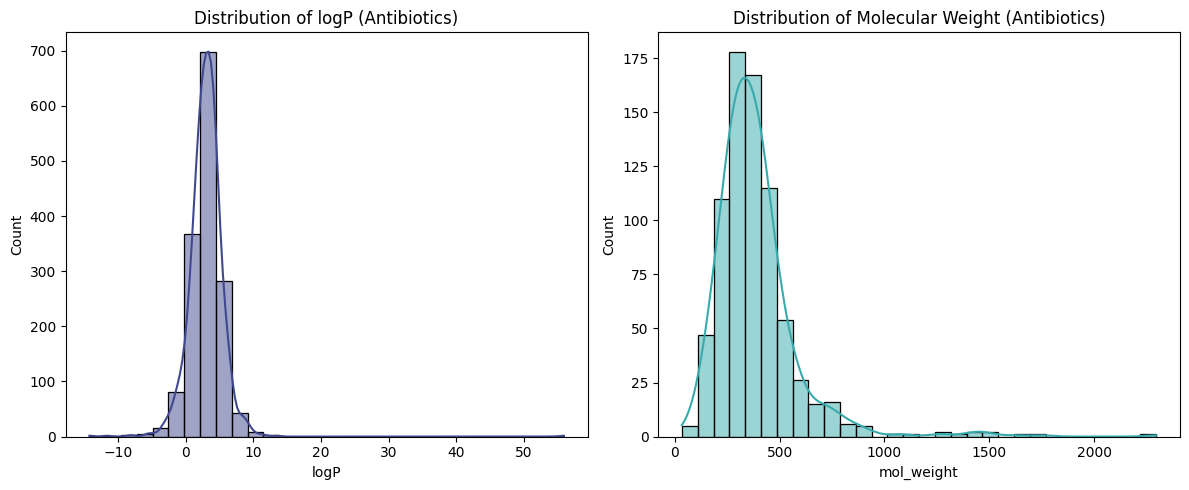

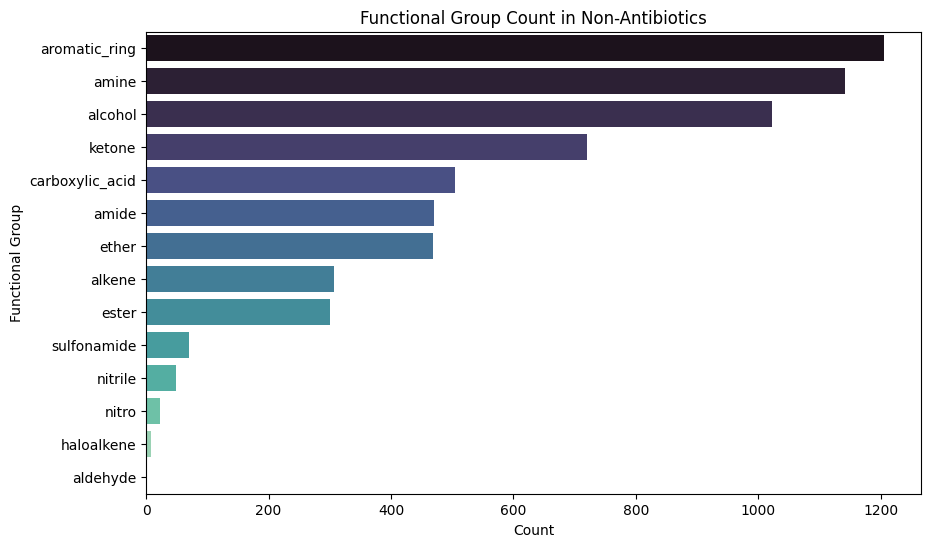

In [341]:

df_non_ab_describe = df_non_ab.loc[:, ~df_non_ab.columns.str.startswith("ECFP4_")]

# stats
display(df_non_ab_describe.describe())


plt.figure(figsize=(12, 5))

mako_colors = sns.color_palette("mako", n_colors=2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_non_ab["logP"], kde=True, bins=30, color=mako_colors[0])
plt.title("Distribution of logP (Antibiotics)")

plt.subplot(1, 2, 2)
df_non_ab["mol_weight"] = df_ab["mol_weight"].astype(float)
sns.histplot(df_ab["mol_weight"], kde=True, bins=30, color=mako_colors[1])
plt.title("Distribution of Molecular Weight (Antibiotics)")

plt.tight_layout()
plt.show()


functional_columns = [
    "carboxylic_acid", "ether", "ester", "amine", "amide", "ketone", "aldehyde",
    "nitrile", "aromatic_ring", "haloalkene", "sulfonamide", "nitro", "alcohol", "alkene"
]

fg_counts = df_non_ab[functional_columns].sum().sort_values(ascending = False)

plt.figure(figsize = (10, 6))
sns.barplot(x = fg_counts.values, y=fg_counts.index, palette = "mako")
plt.title("Functional Group Count in Non-Antibiotics")
plt.xlabel("Count")
plt.ylabel("Functional Group")
plt.show()

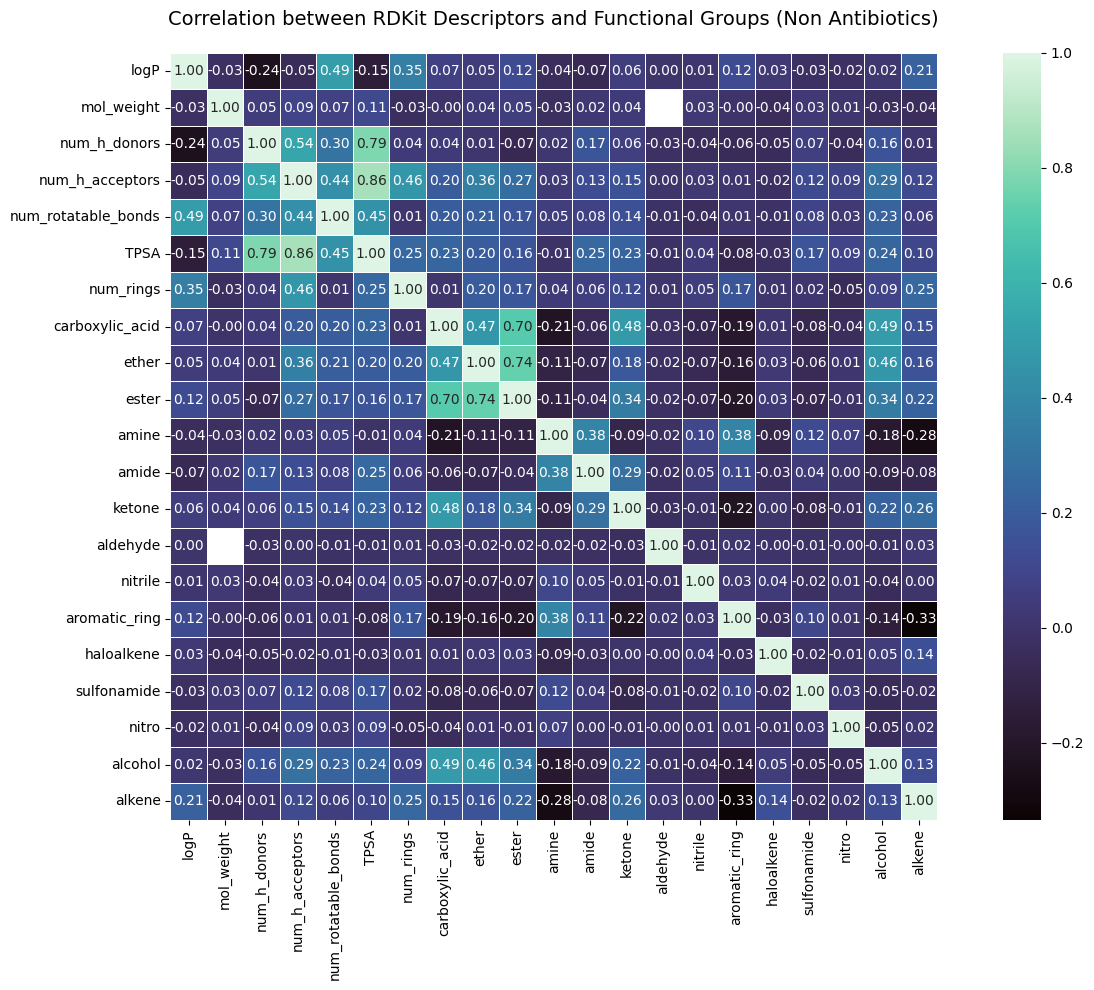

In [342]:
# columns for the heatmap
descriptor_columns = [
    "logP", "mol_weight", "num_h_donors", "num_h_acceptors",
    "num_rotatable_bonds", "TPSA", "num_rings"
]

functional_columns = [
    "carboxylic_acid", "ether", "ester", "amine", "amide", "ketone", "aldehyde",
    "nitrile", "aromatic_ring", "haloalkene", "sulfonamide", "nitro", "alcohol", "alkene"
]


selected_cols = descriptor_columns + functional_columns
df_analysis = df_non_ab[selected_cols].copy()

df_analysis = df_analysis.apply(pd.to_numeric, errors = "coerce")


correlation_matrix = df_analysis.corr()


plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot = True, fmt = ".2f", cmap = "mako", square = True, linewidths = 0.5)
plt.title("Correlation between RDKit Descriptors and Functional Groups (Non Antibiotics)", fontsize = 14, pad = 20)
plt.tight_layout()
plt.show()

**UMAP/PCA on Combined Feature Space**

In [343]:
# merge df
df_combined = pd.concat([df_ab, df_non_ab], ignore_index = True)


columns_to_exclude = ["chembl_id", "smiles"]
df_umap = df_combined.drop(columns = [col for col in columns_to_exclude if col in df_combined.columns])


labels = df_umap["is_antibiotic"].copy()
X = df_umap.drop(columns=["is_antibiotic"])


rows_before = X.shape[0]
X = X.dropna(axis=1)
labels = labels.loc[X.index]
print(f"Rows kept after NaN removal: {X.shape[0]} / {rows_before}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors = 15, min_dist = 0.1, random_state = 42)
embedding = reducer.fit_transform(X_scaled)
print("UMAP completed. Shape:", embedding.shape)

Rows kept after NaN removal: 2262 / 2262
UMAP completed. Shape: (2262, 2)


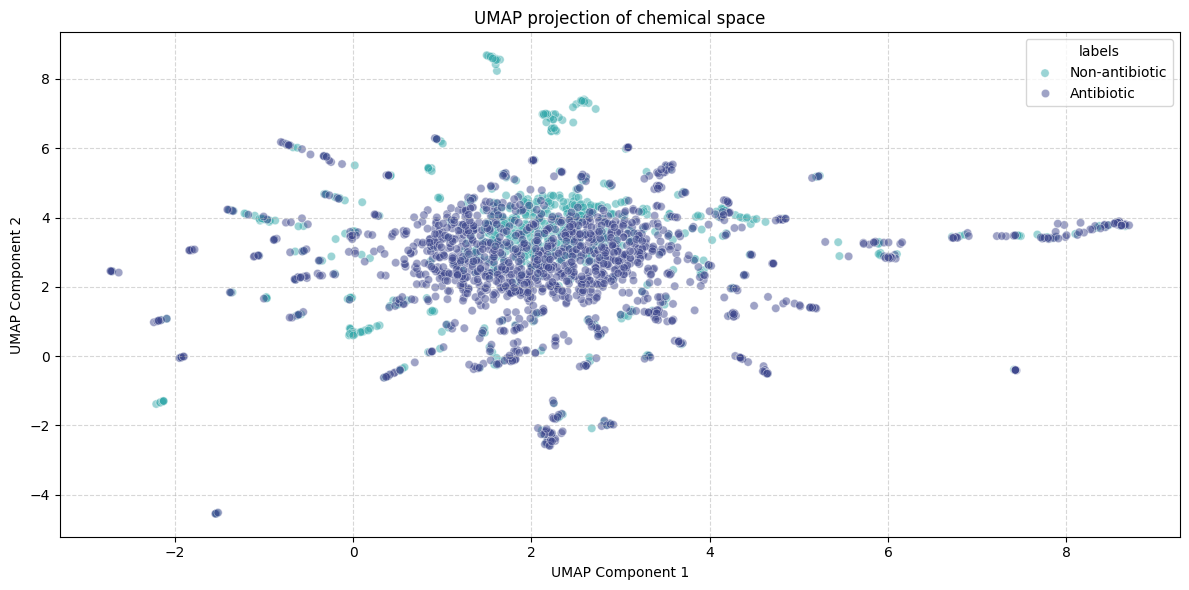

In [344]:
# Plot
df_vis = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
df_vis["is_antibiotic"] = labels.values

plt.figure(figsize = (12, 6))
sns.scatterplot(
    data = df_vis,
    x = "UMAP1", y = "UMAP2",
    hue = "is_antibiotic",
    palette = "mako",
    alpha = 0.5
)
plt.title("UMAP projection of chemical space")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend(title = 'labels', labels = ["Non-antibiotic", "Antibiotic"])
plt.tight_layout()
plt.show()

**k-NN Probability Classification in UMAP Space**

**Clustering in UMAP Space (DBSCAN)**

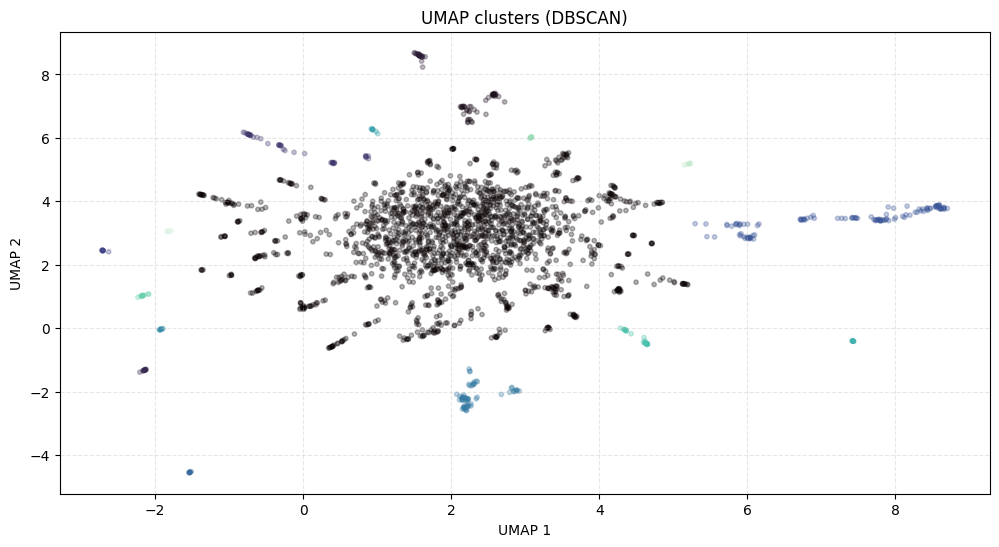

In [345]:
# Apply DBSCAN to find dense clusters in the UMAP space
clustering = DBSCAN(eps = 0.6, min_samples = 5).fit(embedding)
df_combined_umap["cluster"] = clustering.labels_


plt.figure(figsize = (12, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=df_combined_umap["cluster"], cmap = "mako", s = 10, alpha = 0.3)
plt.title("UMAP clusters (DBSCAN)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, linestyle = '--', alpha = 0.3)
plt.show()

In [346]:
# X = 2D UMAP embedding, y = binary labels (0 = non-antibiotic, 1 = antibiotic)
X = embedding
y = df_combined.loc[labels.index, "is_antibiotic"]  # ensure label alignment

# Fit a k-NN classifier
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X, y)

# Predict probabilities
probas = knn.predict_proba(X)[:, 1]  # probability of class 1 (antibiotic)


df_combined_umap = df_combined.loc[labels.index].copy()
df_combined_umap["prob_antibiotic"] = probas

# Filter only high-confidence antibiotic-like molecules (prob. ≥ 80%)
candidates = df_combined_umap[(df_combined_umap["is_antibiotic"] == 0) &
                              (df_combined_umap["prob_antibiotic"] >= 0.80)]

print(f"Top candidates: {candidates.shape[0]} molecules with ≥ 80% probability.")

Top candidates: 15 molecules with ≥ 80% probability.


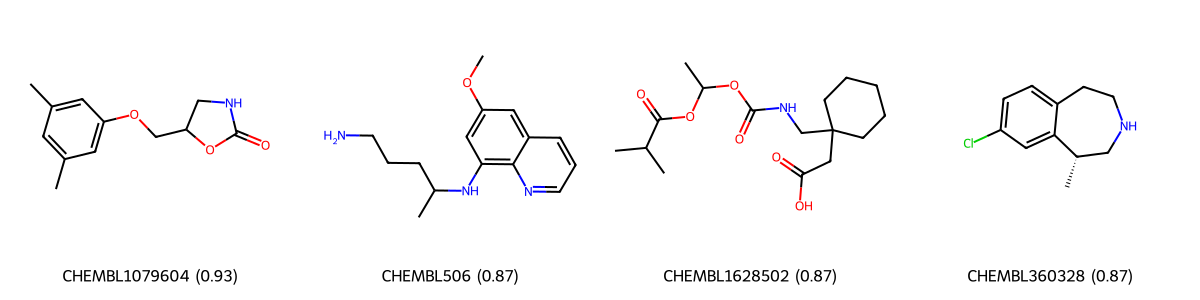

In [347]:
from rdkit.Chem import Draw

# Convert SMILES to RDKit Mol objects
top_mols = [Chem.MolFromSmiles(smi) for smi in top_candidates["smiles"]]

legends = [
    f"{chembl} ({prob:.2f})"
    for chembl, prob in zip(top_candidates["chembl_id"], top_candidates["antibiotic_probability"])
]

# first 12)
img = Draw.MolsToGridImage(
    top_mols[:12],
    molsPerRow = 4,
    subImgSize = (300, 300),
    legends = legends[:12]
)

img

# Top candidates fit within UMAP clsuters

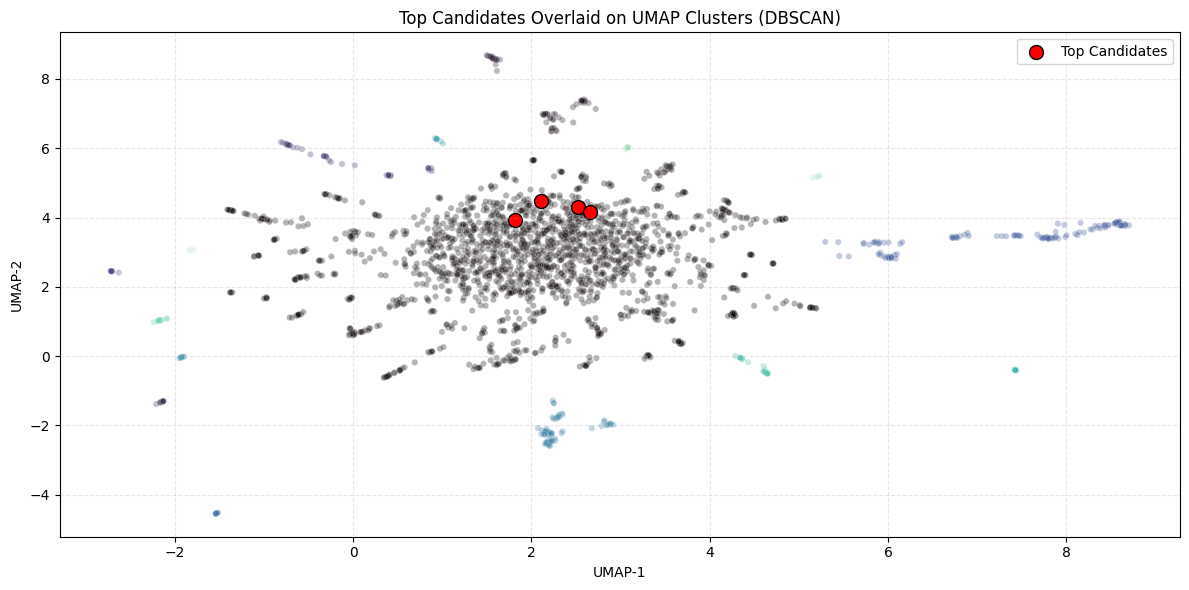

In [348]:
# Apply DBSCAN on the UMAP embedding (X = embedding)
dbscan = DBSCAN(eps=0.6, min_samples = 5)
cluster_labels = dbscan.fit_predict(embedding)

# Assign cluster labels to the full df_combined_umap
df_combined_umap["cluster"] = cluster_labels

# Add UMAP coordinates to df_combined_umap
df_combined_umap["umap_x"] = embedding[:, 0]
df_combined_umap["umap_y"] = embedding[:, 1]


# Merge cluster labels into top_candidates (or 'candidates')
top_candidates_with_clusters = candidates.merge(
    df_combined_umap[["chembl_id", "cluster", "umap_x", "umap_y"]],
    on = "chembl_id",
    how = "left"
)

# Step 2: Filter the 4 top candidates correctly by chembl_id
subset = df_combined_umap[df_combined_umap["chembl_id"].isin(top_candidates["chembl_id"])]

# Step 3: Plot
plt.figure(figsize = (12, 6))
sns.scatterplot(
    x=X[:, 0], y = X[:, 1],
    hue=cluster_labels,
    palette = "mako", s = 20, alpha = 0.3, legend = False
)

# Overlay the top candidates in red
plt.scatter(
    subset["umap_x"], subset["umap_y"],
    c = "red", label = "Top Candidates", s = 100, edgecolor = "black"
)

plt.title("Top Candidates Overlaid on UMAP Clusters (DBSCAN)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.3)
plt.tight_layout()
plt.show()

# Feature vizualization - Top candidates

,chembl_id,logP,molecular_weight
759,CHEMBL1079604,1.79,221.26
1563,CHEMBL506,2.78,259.35
2157,CHEMBL1628502,2.68,329.39
2260,CHEMBL360328,2.59,195.69
Mean (Top Candidates),—,2.46,251.42
Mean (Antibiotics),—,1.73,386.60


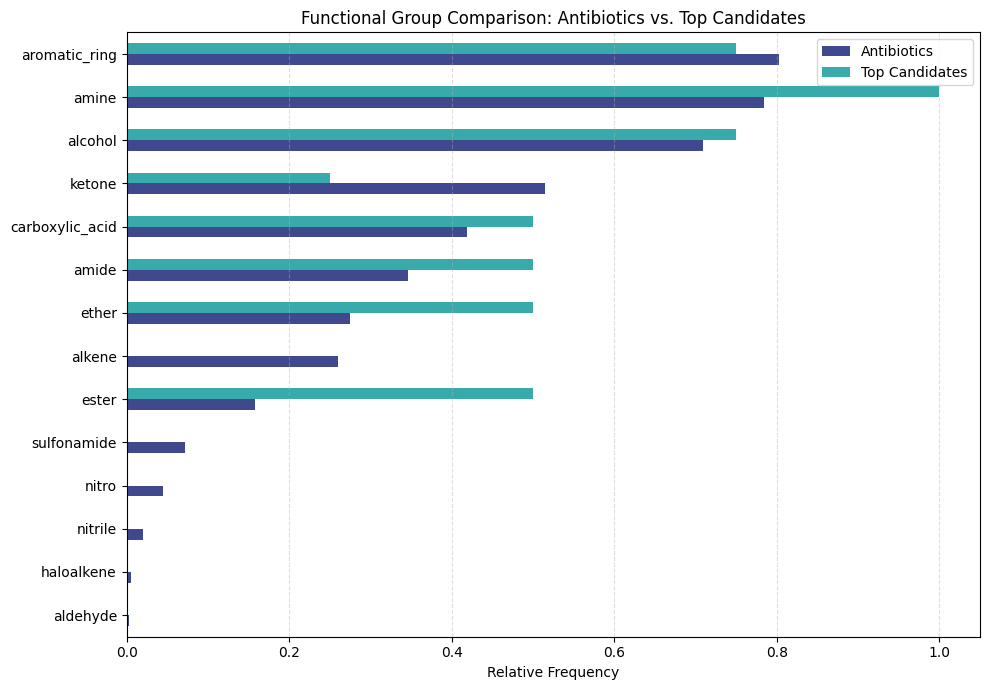

In [349]:
#columns
summary_cols = ["chembl_id", "logP", "molecular_weight"]

summary_top_candidates = top_candidates[summary_cols].copy()

mean_logP_ab = df_ab["logP"].mean()
mean_mol_weight_ab = df_ab["mol_weight"].mean()

summary_top_candidates.loc["Mean (Top Candidates)"] = [
    "—",
    summary_top_candidates["logP"].mean(),
    summary_top_candidates["molecular_weight"].mean()
]

summary_top_candidates.loc["Mean (Antibiotics)"] = [
    "—",
    mean_logP_ab,
    mean_mol_weight_ab
]


# Display the table
pd.options.display.float_format = "{:.2f}".format
display(summary_top_candidates)


df_fg_ab = df_ab[functional_columns]
df_fg_candidates = top_candidates[functional_columns]



fg_ab_counts = df_fg_ab.sum() / df_fg_ab.shape[0]
fg_candidates_counts = df_fg_candidates.sum() / df_fg_candidates.shape[0]

fg_comparison = pd.DataFrame({
    "Antibiotics": fg_ab_counts,
    "Top Candidates": fg_candidates_counts
}).sort_values("Antibiotics", ascending=True)

# Plot
palette = sns.color_palette("mako", 2)

fg_comparison.plot(kind = "barh", figsize = (10, 7), color=palette)
plt.xlabel("Relative Frequency")
plt.title("Functional Group Comparison: Antibiotics vs. Top Candidates")
plt.grid(axis="x", linestyle="--", alpha = 0.4)
plt.tight_layout()
plt.show()

**ECFP4-Only Clustering (DBSCAN on Tanimoto distance)**

In [350]:
# Morgan (ECFP4, 1024 bits)
generator = GetMorganGenerator(radius = 2, fpSize = 1024)

def get_ecfp4_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return generator.GetFingerprint(mol) if mol else None

fps = [get_ecfp4_fingerprint(smi) for smi in df_non_ab["smiles"]]
valid_indices = [i for i, fp in enumerate(fps) if fp is not None]
valid_fps = [fps[i] for i in valid_indices]

# Tanimoto
n = len(valid_fps)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1):
        sim = TanimotoSimilarity(valid_fps[i], valid_fps[j])
        dist = 1 - sim
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist

# DBSCAN clustering
dbscan = DBSCAN(metric="precomputed", eps = 0.3, min_samples = 5)
labels_ecfp = dbscan.fit_predict(dist_matrix)

df_non_ab_ecfp = df_non_ab.iloc[valid_indices].copy()
df_non_ab_ecfp["ecfp4_cluster"] = labels_ecfp

[23:42:10] WARNING: not removing hydrogen atom without neighbors
[23:42:10] WARNING: not removing hydrogen atom without neighbors
[23:42:10] WARNING: not removing hydrogen atom without neighbors
[23:42:10] WARNING: not removing hydrogen atom without neighbors


[23:42:15] WARNING: not removing hydrogen atom without neighbors
[23:42:15] WARNING: not removing hydrogen atom without neighbors
[23:42:15] WARNING: not removing hydrogen atom without neighbors
[23:42:15] WARNING: not removing hydrogen atom without neighbors


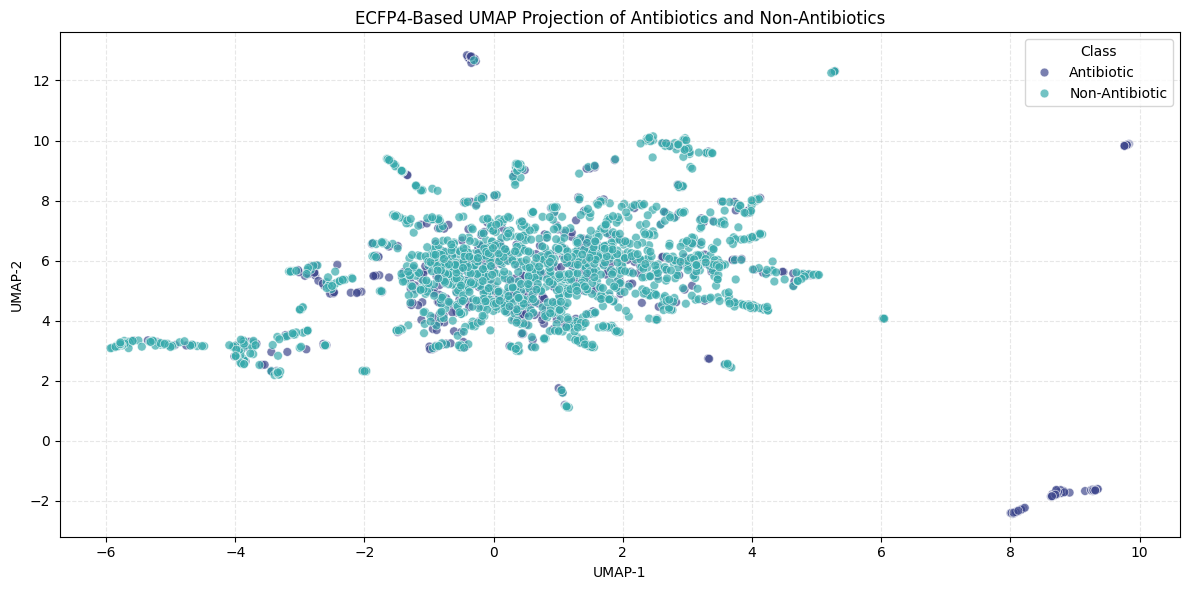

In [351]:
# Combine all (antibiotics + non-antibiotics)
df_all = pd.concat([df_ab, df_non_ab], ignore_index = True).reset_index(drop = True)

# ECFP4
generator = GetMorganGenerator(radius = 2, fpSize = 1024)

def safe_ecfp4(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return generator.GetFingerprint(mol) if mol else None

fps = [safe_ecfp4(smi) for smi in df_all["smiles"]]
valid_idx = [i for i, fp in enumerate(fps) if fp is not None]
valid_fps = [fps[i] for i in valid_idx]


fp_array = []
for fp in valid_fps:
    arr = np.zeros((1024,), dtype = int)
    ConvertToNumpyArray(fp, arr)
    fp_array.append(arr)
fp_array = np.array(fp_array)


valid_df = df_all.loc[valid_idx].copy()
label_colors = valid_df["is_antibiotic"].map({0: "Non-Antibiotic", 1: "Antibiotic"})

# UMAP on ECFP4
reducer = umap.UMAP(n_neighbors = 15, min_dist = 0.1, random_state = 42)
embedding = reducer.fit_transform(fp_array)

# Plot
palette = sns.color_palette("mako", 2)
color_map = {"Antibiotic": palette[0], "Non-Antibiotic": palette[1]}

plt.figure(figsize = (12, 6))
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=label_colors,
    palette=color_map,
    alpha=0.7,
    s=40
)
plt.title("ECFP4-Based UMAP Projection of Antibiotics and Non-Antibiotics")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Class", loc='upper right',frameon=True)
plt.grid(True, linestyle = '--', alpha = 0.3)
plt.tight_layout()
plt.show()

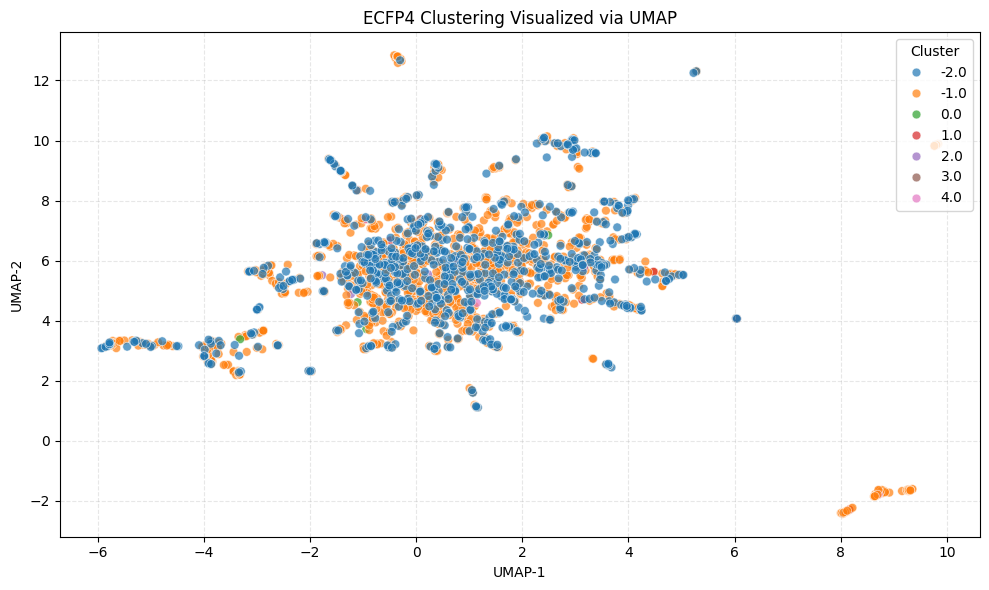

In [352]:
fp_array = []
for fp in valid_fps:
    arr = np.zeros((1024,), dtype = int)
    ConvertToNumpyArray(fp, arr)
    fp_array.append(arr)

fp_array = np.array(fp_array)


reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
ecfp_embedding = reducer.fit_transform(fp_array)


cluster_df_temp = df_non_ab_ecfp.loc[valid_indices, ["ecfp4_cluster"]].reset_index()


df_all_with_clusters = valid_df.merge(
    cluster_df_temp,
    left_index=True,
    right_on="index",
    how="left"
).set_index("index")


aligned_cluster_labels = df_all_with_clusters["ecfp4_cluster"].fillna(-2) # Fill NaN with a distinct value for non-clustered

# Plot with cluster labels
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x = ecfp_embedding[:, 0],
    y = ecfp_embedding[:, 1],
    hue = aligned_cluster_labels,
    palette = "tab10",
    legend = "full",
    s = 40,
    alpha = 0.7
)
plt.title("ECFP4 Clustering Visualized via UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title = "Cluster", loc = "upper right", frameon = True)
plt.grid(True, linestyle = '--', alpha = 0.3)
plt.tight_layout()
plt.show()

# Merge UMAP Results with ECFP4 Clusters (Non-antibiotics only)

In [353]:

labels = df_combined["is_antibiotic"].reset_index(drop = True)  # full labels aligned with df_combined
embedding_valid = embedding  # output from UMAP (already aligned with df_combined)


non_ab_mask = labels == 0  # this now has the correct length

# Filter non-antibiotics
df_non_ab_umap = df_combined[non_ab_mask].copy().reset_index(drop=True)
umap_non_ab = embedding_valid[non_ab_mask]


df_non_ab_umap["umap_x"] = umap_non_ab[:, 0]
df_non_ab_umap["umap_y"] = umap_non_ab[:, 1]

# Merge with ECFP4 cluster
df_merged = df_non_ab_umap.merge(
    df_non_ab_ecfp[["chembl_id", "ecfp4_cluster"]],
    on="chembl_id",
    how="inner"
)

print("Merged shape:", df_merged.shape)# Step 1: Ensure full labels and alignment
labels = df_combined["is_antibiotic"].reset_index(drop = True)  # full labels aligned with df_combined
embedding_valid = embedding  # output from UMAP (already aligned with df_combined)


Merged shape: (1506, 1052)


# Hybrid score as weighted average

In [354]:

if "antibiotic_probability" in df_merged.columns:
    df_merged = df_merged.drop(columns=["antibiotic_probability"])

df_merged = df_merged.merge(
    df_non_ab_filtered[["chembl_id", "antibiotic_probability"]],
    on = "chembl_id",
    how = "left"
)

if "is_clustered" not in df_merged.columns and "ecfp4_cluster" in df_merged.columns:
    df_merged["is_clustered"] = (df_merged["ecfp4_cluster"] != -1).astype(int)

# hybrid score
df_merged["hybrid_score"] = (
    0.8 * df_merged["antibiotic_probability"] + 0.2 * df_merged["is_clustered"]
)

# top candidates
top_hybrid_candidates = df_merged[
    (df_merged["is_antibiotic"] == 0) &
    (df_merged["hybrid_score"] >= 0.7)
].copy()

print(f"Top hybrid candidates found: {top_hybrid_candidates.shape[0]}")
print(top_hybrid_candidates[["chembl_id", "smiles", "hybrid_score"]])

Top hybrid candidates found: 1
       chembl_id                       smiles  hybrid_score
3  CHEMBL1079604  Cc1cc(C)cc(OCC2CNC(=O)O2)c1          0.75


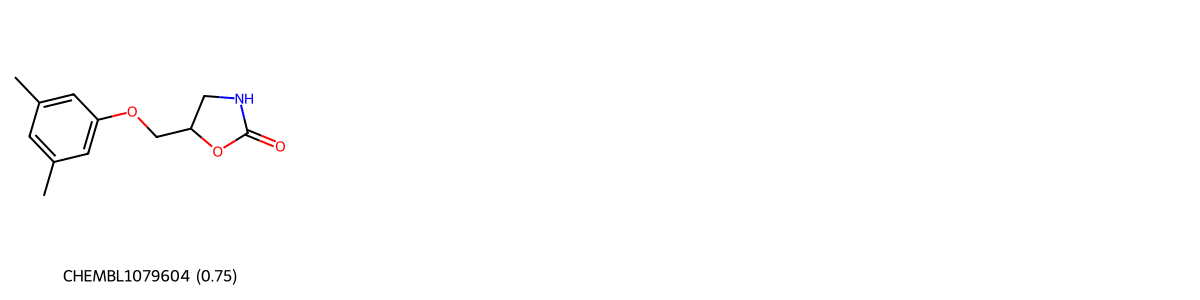

In [355]:

top_hybrid_mols = [Chem.MolFromSmiles(smi) for smi in top_hybrid_candidates["smiles"]]


legends = [
    f"{chembl} ({score:.2f})"
    for chembl, score in zip(top_hybrid_candidates["chembl_id"], top_hybrid_candidates["hybrid_score"])
]

# Plot
img = Draw.MolsToGridImage(
    top_hybrid_mols[:12],
    molsPerRow = 4,
    subImgSize = (300, 300),
    legends = legends[:12]
)

img